In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/casumitmahato/roll-rate-analysis-data-with-no-nr/roll_rate_matrix_no_NR.parquet
/kaggle/input/datasets/casumitmahato/macro-economic-variable-of-usa/us_macroeconomic_data_2010_2030.csv


In [2]:
import pandas as pd, numpy as np, gc, os, time
import pyarrow.parquet as pq
from datetime import datetime
from scipy.stats import norm
import pytz

IST = pytz.timezone("Asia/Kolkata")
def ist_now(label=""):
    print(f"[{datetime.now(IST).strftime('%d-%b-%Y  %H:%M:%S IST')}]  {label}", flush=True)

FILE_PATH    = "/kaggle/input/datasets/casumitmahato/roll-rate-analysis-data-with-no-nr/roll_rate_matrix_no_NR.parquet"
WORKING_DIR  = "/kaggle/working"
ACCUM_PATH   = f"{WORKING_DIR}/roll12_accum_partial.parquet"
PROGRESS_FILE = f"{WORKING_DIR}/roll12_progress.txt"
CKPT_FINAL   = f"{WORKING_DIR}/roll_rate_12m_transition.parquet"
BATCH_SIZE   = 500_000

os.makedirs(WORKING_DIR, exist_ok=True)
t_start = time.time()

In [3]:
pf = pq.ParquetFile(FILE_PATH)
all_cols = pf.schema_arrow.names
month_cols = [c for c in all_cols if c != "LOAN_ID"]
month_cols_sorted = sorted(month_cols)

pairs = []
for i in range(len(month_cols_sorted) - 12):
    B = month_cols_sorted[i]
    M = month_cols_sorted[i + 12]
    pairs.append((B, M))

total_rows_in = pf.metadata.num_rows
n_batches = (total_rows_in + BATCH_SIZE - 1) // BATCH_SIZE
print(f"total months={len(month_cols_sorted)}  pairs={len(pairs)}  loans={total_rows_in:,}  batches={n_batches}")

total months=72  pairs=60  loans=1,364,438  batches=3


In [4]:
import os

for f in [ACCUM_PATH, PROGRESS_FILE]:
    if os.path.exists(f):
        os.remove(f)
        print(f"removed {f}")
    else:
        print(f"not found: {f}")

not found: /kaggle/working/roll12_accum_partial.parquet
not found: /kaggle/working/roll12_progress.txt


In [6]:
import pandas as pd, numpy as np, gc, os, time
import pyarrow.parquet as pq

t_start = time.time()

pf2 = pq.ParquetFile(FILE_PATH)
all_cols2 = pf2.schema_arrow.names
month_cols2 = [c for c in all_cols2 if c != "LOAN_ID"]
total_rows_in2 = pf2.metadata.num_rows
n_batches2 = (total_rows_in2 + BATCH_SIZE - 1) // BATCH_SIZE

dpd_buckets = ["1-30 DPD", "31-60 DPD", "61-90 DPD", "91+ DPD"]
counts = {b: {m: 0 for m in month_cols2} for b in dpd_buckets}
total_loans_seen = 0

for batch in pf2.iter_batches(batch_size=BATCH_SIZE):
    df = batch.to_pandas()
    df_status = df[month_cols2].astype(str)

    for m in month_cols2:
        col = df_status[m]
        counts["1-30 DPD"][m]  += (col == "1").sum()
        counts["31-60 DPD"][m] += (col == "2").sum()
        counts["61-90 DPD"][m] += (col == "3").sum()
        numeric = pd.to_numeric(col, errors="coerce")
        counts["91+ DPD"][m]   += (numeric > 3).sum()

    total_loans_seen += len(df)
    del df, df_status, col, numeric
    gc.collect()

rate_df = pd.DataFrame({
    b: {m: counts[b][m] / total_loans_seen for m in month_cols2}
    for b in dpd_buckets
}).T
rate_df = rate_df[month_cols2]

print(f"Done in {time.time()-t_start:.1f}s. Total loans = {total_loans_seen:,}")
rate_df

Done in 104.9s. Total loans = 1,364,438


,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,...,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
1-30 DPD,0.006351,0.007478,0.005742,0.006094,0.006324,0.007172,0.006932,0.006859,0.009494,0.007885,...,0.008091,0.010416,0.009279,0.009355,0.009874,0.009631,0.010602,0.010239,0.011011,0.012066
31-60 DPD,0.001420,0.001391,0.001150,0.001039,0.001102,0.001221,0.001272,0.001231,0.001512,0.001497,...,0.002249,0.002252,0.002307,0.002257,0.002518,0.002495,0.002571,0.002710,0.002817,0.002979
61-90 DPD,0.001113,0.000910,0.000806,0.000589,0.000457,0.000449,0.000467,0.000444,0.000520,0.000556,...,0.000973,0.001098,0.000959,0.001005,0.001027,0.001069,0.001093,0.001114,0.001202,0.001249
91+ DPD,0.001586,0.001779,0.001763,0.001828,0.001697,0.001504,0.001339,0.001243,0.001272,0.001323,...,0.005706,0.005465,0.005261,0.005096,0.005042,0.004903,0.004921,0.004855,0.004923,0.004940


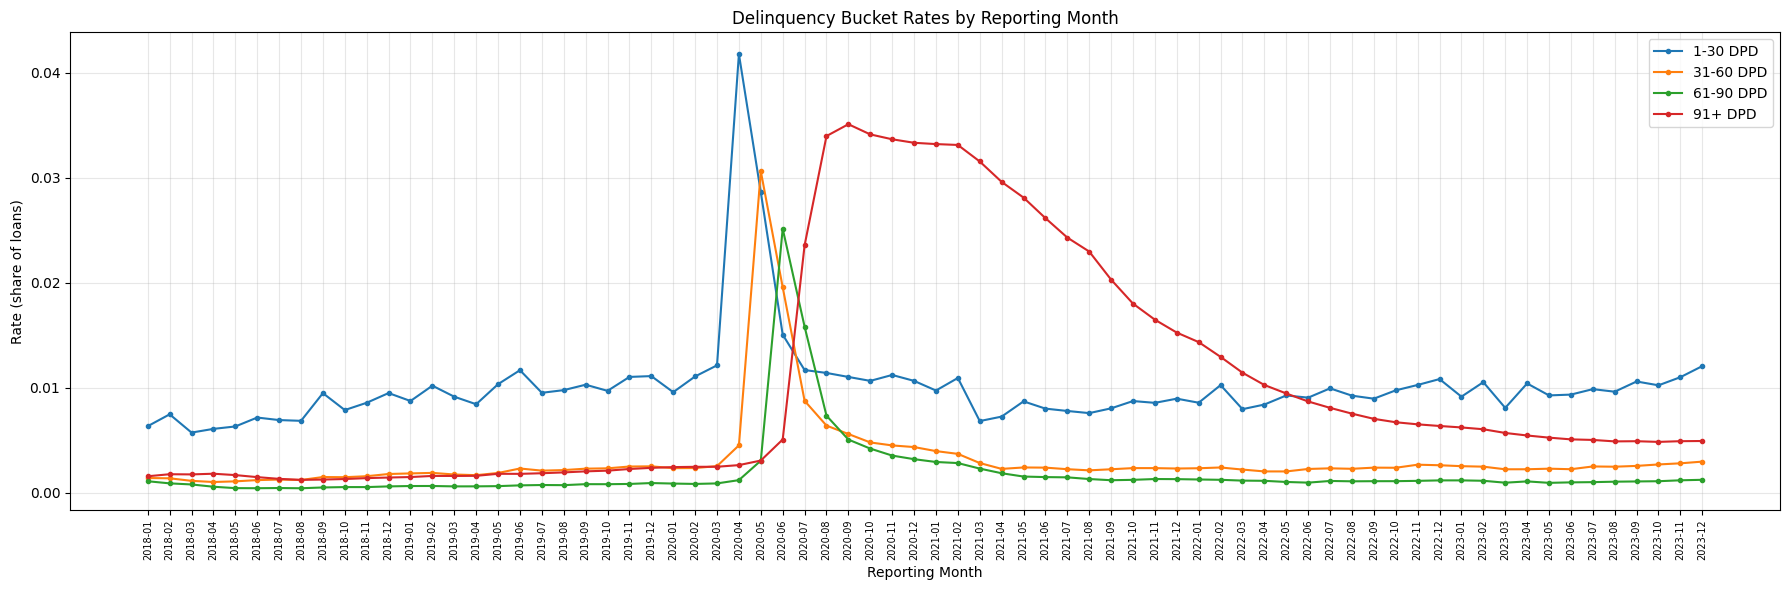

✓ Plot saved → /kaggle/working/dpd_rate_trend.png


In [7]:
import matplotlib.pyplot as plt

dpd_buckets = ["1-30 DPD", "31-60 DPD", "61-90 DPD", "91+ DPD"]

fig, ax = plt.subplots(figsize=(18, 6))
for b in dpd_buckets:
    ax.plot(rate_df.columns, rate_df.loc[b], marker="o", markersize=3, label=b, linewidth=1.5)
ax.set_xlabel("Reporting Month")
ax.set_ylabel("Rate (share of loans)")
ax.set_title("Delinquency Bucket Rates by Reporting Month")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()

plot_path = f"{WORKING_DIR}/dpd_rate_trend.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"✓ Plot saved → {plot_path}")

In [8]:
buckets = ["Current", "1-30 DPD", "31-60 DPD", "61-90 DPD", "ODR"]

if os.path.exists(ACCUM_PATH) and os.path.exists(PROGRESS_FILE):
    accum = pd.read_parquet(ACCUM_PATH)
    num = {b: accum.loc[f"{b}_num"].to_dict() for b in buckets}
    den = {b: accum.loc[f"{b}_den"].to_dict() for b in buckets}
    with open(PROGRESS_FILE) as f:
        last_batch_done = int(f.read().strip())
    print(f"resuming from batch {last_batch_done + 1}")
else:
    num = {b: {B: 0 for B, M in pairs} for b in buckets}
    den = {b: {B: 0 for B, M in pairs} for b in buckets}
    last_batch_done = -1

In [9]:
batch_idx = 0
total_seen = 0

for batch in pf.iter_batches(batch_size=BATCH_SIZE, columns=month_cols):
    if batch_idx <= last_batch_done:
        total_seen += batch.num_rows
        batch_idx += 1
        continue

    t0 = time.time()
    df = batch.to_pandas()

    needed_cols = set()
    for B, M in pairs:
        needed_cols.add(B); needed_cols.add(M)
    df_num = df[list(needed_cols)].apply(pd.to_numeric, errors="coerce")

    for B, M in pairs:
        b_col = df_num[B]
        m_col = df_num[M]

        mask_b0 = b_col == 0
        num["Current"][B]  += ((mask_b0) & (m_col > 3)).sum()
        den["Current"][B]  += mask_b0.sum()

        mask_b1 = b_col == 1
        num["1-30 DPD"][B]  += ((mask_b1) & (m_col == 4)).sum()
        den["1-30 DPD"][B]  += mask_b1.sum()

        mask_b2 = b_col == 2
        num["31-60 DPD"][B] += ((mask_b2) & (m_col == 4)).sum()
        den["31-60 DPD"][B] += mask_b2.sum()

        mask_b3 = b_col == 3
        num["61-90 DPD"][B] += ((mask_b3) & (m_col == 4)).sum()
        den["61-90 DPD"][B] += mask_b3.sum()

        mask_odr = b_col.isin([0, 1, 2, 3])
        num["ODR"][B] += ((mask_odr) & (m_col > 3)).sum()
        den["ODR"][B] += mask_odr.sum()

    total_seen += len(df)

    rows = {}
    for b in buckets:
        rows[f"{b}_num"] = num[b]
        rows[f"{b}_den"] = den[b]

    accum_df = pd.DataFrame(rows)
    accum_df.to_parquet(ACCUM_PATH)
    with open(PROGRESS_FILE, "w") as f:
        f.write(str(batch_idx))

    ist_now(f"  ✓ batch {batch_idx+1}/{n_batches}  loans_seen={total_seen:,}  ({time.time()-t0:.1f}s)")

    del df, df_num, b_col, m_col, mask_b0, mask_b1, mask_b2, mask_b3, mask_odr
    gc.collect()
    batch_idx += 1

ist_now(f"STAGE ► Counting complete. Total loans scanned = {total_seen:,}")

[22-Jun-2026  09:06:23 IST]    ✓ batch 1/3  loans_seen=500,000  (23.4s)
[22-Jun-2026  09:06:47 IST]    ✓ batch 2/3  loans_seen=1,000,000  (23.5s)
[22-Jun-2026  09:07:05 IST]    ✓ batch 3/3  loans_seen=1,364,438  (17.3s)
[22-Jun-2026  09:07:06 IST]  STAGE ► Counting complete. Total loans scanned = 1,364,438


In [11]:
ist_now("STAGE ► Converting counts to rates …")

B_cols = [B for B, M in pairs]
result = pd.DataFrame(index=buckets, columns=B_cols, dtype=float)

for b in buckets:
    for B in B_cols:
        d = den[b][B]
        result.loc[b, B] = (num[b][B] / d * 100) if d > 0 else np.nan

result.to_parquet(CKPT_FINAL)
print(result.iloc[:, :6])

[22-Jun-2026  09:09:11 IST]  STAGE ► Converting counts to rates …
            2018-01   2018-02   2018-03   2018-04   2018-05   2018-06
Current    0.076362  0.081340  0.087678  0.087612  0.097457  0.093163
1-30 DPD   1.061620  1.127119  1.263722  1.070355  1.216827  1.277335
31-60 DPD  1.703665  1.317176  2.103250  2.256700  2.328676  2.220888
61-90 DPD  1.449275  1.208703  1.000000  1.990050  2.086677  2.777778
ODR        0.125892  0.134581  0.135459  0.135909  0.152262  0.151426


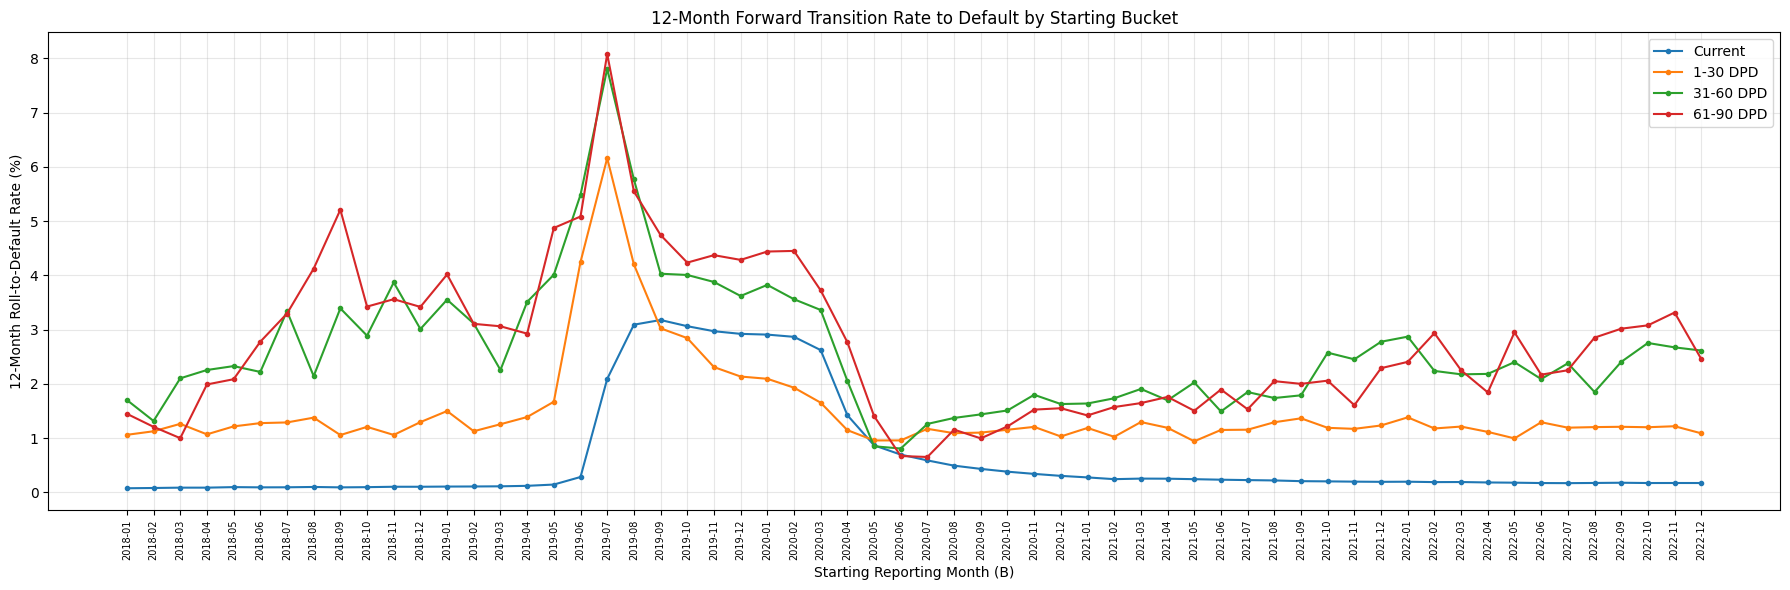

✓ Plot saved → /kaggle/working/bucket_transition_trend.png


In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 6))

for b in buckets:
    if b == "ODR":
        continue
    ax.plot(result.columns, result.loc[b], marker="o", markersize=3, label=b, linewidth=1.5)

ax.set_xlabel("Starting Reporting Month (B)")
ax.set_ylabel("12-Month Roll-to-Default Rate (%)")
ax.set_title("12-Month Forward Transition Rate to Default by Starting Bucket")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()

plot_path = f"{WORKING_DIR}/bucket_transition_trend.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"✓ Plot saved → {plot_path}")

In [13]:
years = ["2018", "2019", "2020", "2021", "2022"]
yearly = pd.DataFrame(index=result.index, columns=years, dtype=float)

for y in years:
    cols_for_year = [c for c in result.columns if str(c).startswith(y)]
    yearly[y] = result[cols_for_year].mean(axis=1) if cols_for_year else np.nan

yearly

,2018,2019,2020,2021,2022
Current,0.092987,1.516755,1.161192,0.229734,0.179648
1-30 DPD,1.192217,2.656538,1.292064,1.183901,1.191568
31-60 DPD,2.548553,4.254690,1.956615,1.973791,2.387129
61-90 DPD,2.796104,4.529283,2.047197,1.778722,2.628235
ODR,0.156074,1.691767,1.865592,0.379306,0.298217


In [14]:
mev = pd.read_csv("/kaggle/input/datasets/casumitmahato/macro-economic-variable-of-usa/us_macroeconomic_data_2010_2030.csv")
mev['Year'] = mev['Year'].astype(float).astype(int)
mev

,Year,Real_GDP_Index,Real_GDP_Growth_Pct,Bank_Credit_Index,Bank_Credit_Growth_Pct,PPI_WPI_Index,PPI_WPI_Growth_Pct,CPI_Index,CPI_Growth_Pct,Ind_Prod_Index,Ind_Prod_Growth_Pct,Case_Shiller_Index,Case_Shiller_Growth_Pct,FHFA_HPI_Index,FHFA_HPI_Growth_Pct,Unemployment_Rate,Crude_Oil_Price,Policy_Interest_Rate
0,2010,16789.750500,0.026952,8910.228325,-0.003407,184.733333,0.068389,218.076167,0.016366,91.737033,0.055667,144.668750,-0.026089,324.635000,-0.040833,0.096083,79.395000,0.001750
1,2011,17052.410500,0.015644,8976.689102,0.007459,201.050000,0.088326,224.923000,0.031397,94.639558,0.031640,139.250667,-0.037452,312.067500,-0.038713,0.089333,94.874167,0.001017
2,2012,17442.759250,0.022891,9406.842640,0.047919,202.158333,0.005513,229.586083,0.020732,97.540858,0.030656,140.983500,0.012444,311.230000,-0.002684,0.080750,94.110833,0.001400
3,2013,17812.167000,0.021178,9723.687060,0.033682,203.408333,0.006183,232.951750,0.014660,99.484375,0.019925,154.511167,0.095952,322.852500,0.037344,0.073583,97.905833,0.001075
4,2014,18261.714250,0.025238,10198.125223,0.048792,205.316667,0.009382,236.715000,0.016155,102.447650,0.029786,164.684583,0.065843,338.865000,0.049597,0.061583,93.258333,0.000892
5,2015,18799.622000,0.029455,10990.651475,0.077713,190.441667,-0.072449,237.001750,0.001211,100.971950,-0.014404,172.159667,0.045390,356.245000,0.051289,0.052750,48.688333,0.001325
6,2016,19141.672250,0.018195,11791.945113,0.072907,185.375000,-0.026605,240.005417,0.012674,98.798758,-0.021523,180.901667,0.050778,374.822500,0.052148,0.048750,43.144167,0.003950
7,2017,19612.102500,0.024576,12295.785644,0.042728,193.533333,0.044010,245.121000,0.021314,99.999992,0.012158,191.364833,0.057839,395.027500,0.053906,0.043583,50.884167,0.010017
8,2018,20193.895250,0.029665,12766.304394,0.038267,201.950000,0.043489,251.099500,0.024390,103.163000,0.031630,202.438000,0.057864,416.835000,0.055205,0.038917,64.938333,0.018317
9,2019,20715.671500,0.025838,13507.394773,0.058051,199.841667,-0.010440,255.652583,0.018133,102.346292,-0.007917,209.416083,0.034470,436.165000,0.046373,0.036750,56.984167,0.021583


In [15]:
odr_years = [2018, 2019, 2020, 2021, 2022]
odr_years_str = [str(y) for y in odr_years]

odr_row_label = [idx for idx in yearly.index if str(idx).strip().lower() == 'odr'][0]
odr = yearly.loc[odr_row_label, odr_years_str].astype(float)
odr.index = odr_years

In [16]:
expected_sign_map = {
    'Real_GDP_Index':            -1,
    'Real_GDP_Growth_Pct':       -1,
    'Bank_Credit_Index':          1,
    'Bank_Credit_Growth_Pct':     1,
    'PPI_WPI_Index':              1,
    'PPI_WPI_Growth_Pct':         1,
    'CPI_Index':                  1,
    'CPI_Growth_Pct':             1,
    'Ind_Prod_Index':            -1,
    'Ind_Prod_Growth_Pct':       -1,
    'Case_Shiller_Index':        -1,
    'Case_Shiller_Growth_Pct':   -1,
    'FHFA_HPI_Index':            -1,
    'FHFA_HPI_Growth_Pct':       -1,
    'Unemployment_Rate':          1,
    'Crude_Oil_Price':            1,
    'Policy_Interest_Rate':       1,
}

expected_sign_table = pd.DataFrame({
    'MEV': list(expected_sign_map.keys()),
    'Expected Sign': ['+' if v == 1 else '-' for v in expected_sign_map.values()]
})
expected_sign_table

,MEV,Expected Sign
0,Real_GDP_Index,-
1,Real_GDP_Growth_Pct,-
2,Bank_Credit_Index,+
3,Bank_Credit_Growth_Pct,+
4,PPI_WPI_Index,+
5,PPI_WPI_Growth_Pct,+
6,CPI_Index,+
7,CPI_Growth_Pct,+
8,Ind_Prod_Index,-
9,Ind_Prod_Growth_Pct,-


In [17]:
mev_sub = mev[mev['Year'].isin(odr_years)].set_index('Year').loc[odr_years]
mev_vars = list(mev_sub.columns)

result_corr = mev_sub[mev_vars].T

result_corr['correlation'] = result_corr.apply(
    lambda row: np.corrcoef(row.values.astype(float), odr.values)[0, 1], axis=1
)
result_corr['sign'] = np.where(result_corr['correlation'] >= 0, '+', '-')
result_corr['expected_sign'] = result_corr.index.map(expected_sign_map).map({1: '+', -1: '-'})

result_corr['strength_test'] = np.where(result_corr['correlation'].abs() > 0.50, 'Pass', 'Fail')
result_corr['sign_test'] = np.where(result_corr['sign'] == result_corr['expected_sign'], 'Pass', 'Fail')
result_corr['overall_test'] = np.where(
    (result_corr['strength_test'] == 'Pass') & (result_corr['sign_test'] == 'Pass'), 'Pass', 'Fail'
)

result_corr

Year,2018,2019,2020,2021,2022,correlation,sign,expected_sign,strength_test,sign_test,overall_test
Real_GDP_Index,20193.895250,20715.671500,20284.500000,21532.407000,22075.931250,-0.459614,-,-,Fail,Pass,Fail
Real_GDP_Growth_Pct,0.029665,0.025838,-0.020814,0.061520,0.025242,-0.681034,-,-,Pass,Pass,Pass
Bank_Credit_Index,12766.304394,13507.394773,14704.672983,15682.898004,17108.485121,-0.254760,-,+,Fail,Fail,Fail
Bank_Credit_Growth_Pct,0.038267,0.058051,0.088639,0.066525,0.090901,0.291124,+,+,Fail,Pass,Fail
PPI_WPI_Index,201.950000,199.841667,194.375000,227.344417,264.481000,-0.602539,-,+,Pass,Fail,Fail
PPI_WPI_Growth_Pct,0.043489,-0.010440,-0.027355,0.169618,0.163349,-0.791744,-,+,Pass,Fail,Fail
CPI_Index,251.099500,255.652583,258.855750,270.973417,292.626417,-0.409511,-,+,Fail,Fail,Fail
CPI_Growth_Pct,0.024390,0.018133,0.012529,0.046812,0.079908,-0.658052,-,+,Pass,Fail,Fail
Ind_Prod_Index,103.163000,102.346292,95.088517,99.287583,100.979983,-0.513014,-,-,Pass,Pass,Pass
Ind_Prod_Growth_Pct,0.031630,-0.007917,-0.070914,0.044160,0.017045,-0.869906,-,-,Pass,Pass,Pass


In [18]:
selected_vars = result_corr[result_corr['overall_test'] == 'Pass'].index

final_table = result_corr.loc[selected_vars, odr_years].copy()
final_table['mean'] = final_table[odr_years].mean(axis=1)
final_table['std_dev_sample'] = final_table[odr_years].std(axis=1, ddof=1)

final_table

Year,2018,2019,2020,2021,2022,mean,std_dev_sample
Real_GDP_Growth_Pct,0.029665,0.025838,-0.020814,0.061520,0.025242,0.024290,0.029380
Ind_Prod_Index,103.163000,102.346292,95.088517,99.287583,100.979983,100.173075,3.199627
Ind_Prod_Growth_Pct,0.031630,-0.007917,-0.070914,0.044160,0.017045,0.002801,0.045534
Case_Shiller_Growth_Pct,0.057864,0.034470,0.060517,0.170543,0.147485,0.094176,0.060601
FHFA_HPI_Growth_Pct,0.055205,0.046373,0.051729,0.137342,0.164606,0.091051,0.055634
Unemployment_Rate,0.038917,0.036750,0.081000,0.053500,0.036500,0.049333,0.019050


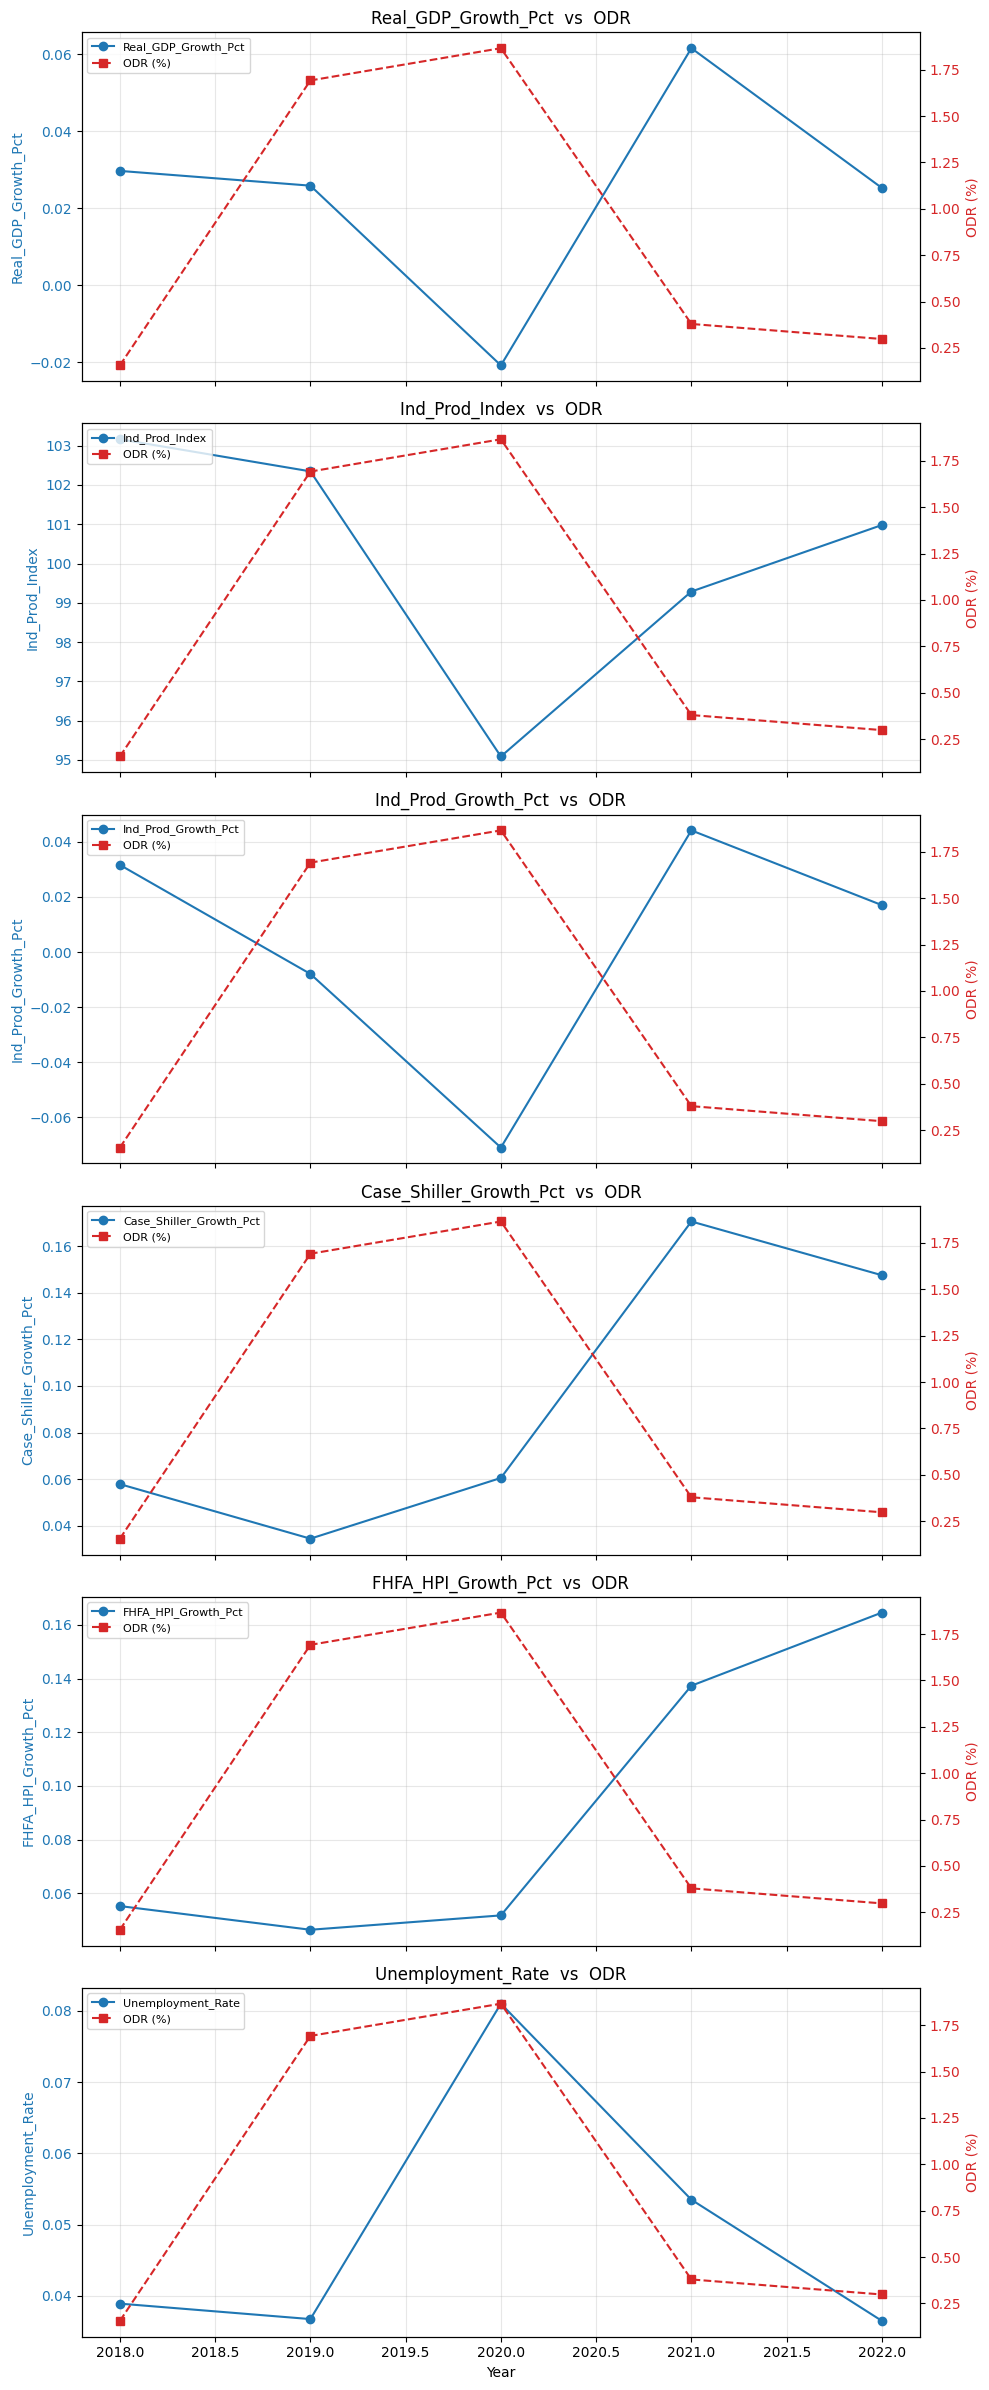

✓ Plot saved → /kaggle/working/selected_mev_vs_odr.png


In [19]:
import matplotlib.pyplot as plt

n_vars = len(selected_vars)
fig, axes = plt.subplots(n_vars, 1, figsize=(10, 4 * n_vars), sharex=True)
if n_vars == 1:
    axes = [axes]

for ax, var in zip(axes, selected_vars):
    ax2 = ax.twinx()

    l1, = ax.plot(odr_years, mev_sub.loc[odr_years, var].astype(float).values,
                   marker="o", color="tab:blue", linewidth=1.5, label=var)
    l2, = ax2.plot(odr_years, odr.values,
                    marker="s", color="tab:red", linewidth=1.5, linestyle="--", label="ODR (%)")

    ax.set_ylabel(var, color="tab:blue")
    ax2.set_ylabel("ODR (%)", color="tab:red")
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax.set_title(f"{var}  vs  ODR")
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[l1, l2], loc="upper left", fontsize=8)

axes[-1].set_xlabel("Year")
plt.tight_layout()

plot_path = f"{WORKING_DIR}/selected_mev_vs_odr.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"✓ Plot saved → {plot_path}")

In [20]:
future_years = [2023, 2024, 2025, 2026, 2027]

mev_future = mev[mev['Year'].isin(future_years)].set_index('Year').loc[future_years]
future_table = mev_future[selected_vars].T

baseline = future_table.copy()
sd = final_table.loc[baseline.index, 'std_dev_sample']

optimistic = baseline.add(sd, axis=0)
pessimistic = baseline.sub(sd, axis=0)

In [21]:
mean = final_table.loc[baseline.index, 'mean']
sd = final_table.loc[baseline.index, 'std_dev_sample']

def standardize(df):
    return df.sub(mean, axis=0).div(sd, axis=0)

baseline_z = standardize(baseline)
optimistic_z = standardize(optimistic)
pessimistic_z = standardize(pessimistic)

combined_z_wide = pd.concat(
    [baseline_z, optimistic_z, pessimistic_z],
    axis=1,
    keys=['baseline', 'optimistic', 'pessimistic']
)

combined_z_wide

baseline                                          \
Year                         2023      2024      2025      2026      2027   
Real_GDP_Growth_Pct      0.171998  0.123946 -0.109838 -0.077958 -0.214107   
Ind_Prod_Index           0.184772 -0.021028  0.329051  0.866877  1.446020   
Ind_Prod_Growth_Pct     -0.108426 -0.205030  0.184226  0.311837  0.333798   
Case_Shiller_Growth_Pct -1.141484 -0.711391 -1.186453 -1.224001 -1.058988   
FHFA_HPI_Growth_Pct     -0.698774 -0.640971 -0.944975 -1.277123 -1.097376   
Unemployment_Rate       -0.686772 -0.476804 -0.351538 -0.174974 -0.227466   

                        optimistic                                          \
Year                          2023      2024      2025      2026      2027   
Real_GDP_Growth_Pct       1.171998  1.123946  0.890162  0.922042  0.785893   
Ind_Prod_Index            1.184772  0.978972  1.329051  1.866877  2.446020   
Ind_Prod_Growth_Pct       0.891574  0.794970  1.184226  1.311837  1.333798   
Case_Shiller_Growth_Pct  -0.141484  0.288609 -0.186453 -0.224001 -0.058988   
FHFA_HPI_Growth_Pct       0.301226  0.359029  0.055025 -0.277123 -0.097376   
Unemployment_Rate         0.313228  0.523196  0.648462  0.825026  0.772534   

                        pessimistic                                          
Year                           2023      2024      2025      2026      2027  
Real_GDP_Growth_Pct       -0.828002 -0.876054 -1.109838 -1.077958 -1.214107  
Ind_Prod_Index            -0.815228 -1.021028 -0.670949 -0.133123  0.446020  
Ind_Prod_Growth_Pct       -1.108426 -1.205030 -0.815774 -0.688163 -0.666202  
Case_Shiller_Growth_Pct   -2.141484 -1.711391 -2.186453 -2.224001 -2.058988  
FHFA_HPI_Growth_Pct       -1.698774 -1.640971 -1.944975 -2.277123 -2.097376  
Unemployment_Rate         -1.686772 -1.476804 -1.351538 -1.174974 -1.227466

In [22]:
n_vars = combined_z_wide.shape[0]
weight = 1 / n_vars

final_economic_factor = (combined_z_wide * weight).sum(axis=0)
final_economic_factor = final_economic_factor.clip(lower=-2.33, upper=2.33)

final_economic_factor_table = final_economic_factor.to_frame().T
final_economic_factor_table.index = ['Final Economic Factor']

final_economic_factor_table

baseline                                         \
Year                       2023     2024      2025      2026      2027   
Final Economic Factor -0.379781 -0.32188 -0.346588 -0.262557 -0.136353   

                      optimistic                                         \
Year                        2023     2024      2025      2026      2027   
Final Economic Factor   0.620219  0.67812  0.653412  0.737443  0.863647   

                      pessimistic                                         
Year                         2023     2024      2025      2026      2027  
Final Economic Factor   -1.379781 -1.32188 -1.346588 -1.262557 -1.136353

In [23]:
vasicek_table = pd.DataFrame({
    'Bucket': yearly.index,
    'TTC_PD': (yearly[odr_years_str].astype(float).mean(axis=1) / 100).values,
    'Asset_Correlation': 0.15
})
vasicek_table = vasicek_table.set_index('Bucket')

vasicek_table = vasicek_table.drop(index='ODR')  # drop ODR row

print(vasicek_table)

def pit_pd(ttc_pd, rho, z):
    val = norm.cdf((norm.ppf(ttc_pd) - np.sqrt(rho) * z) / np.sqrt(1 - rho))
    return max(val, 0.0015)

scenarios = ['baseline', 'optimistic', 'pessimistic']
pd_columns = {}

for scenario in scenarios:
    for year in future_years:
        z = final_economic_factor[(scenario, year)]
        col_values = vasicek_table.apply(
            lambda row: pit_pd(row['TTC_PD'], row['Asset_Correlation'], z), axis=1
        )
        pd_columns[(scenario, year)] = col_values

pd_block = pd.DataFrame(pd_columns)
pd_block.columns = pd.MultiIndex.from_tuples(pd_block.columns, names=['scenario', 'year'])

vasicek_merton_table = pd.concat([vasicek_table, pd_block], axis=1)

vasicek_merton_table

             TTC_PD  Asset_Correlation
Bucket                                
Current    0.006361               0.15
1-30 DPD   0.015033               0.15
31-60 DPD  0.026242               0.15
61-90 DPD  0.027559               0.15


,TTC_PD,Asset_Correlation,"(baseline, 2023)","(baseline, 2024)","(baseline, 2025)","(baseline, 2026)","(baseline, 2027)","(optimistic, 2023)","(optimistic, 2024)","(optimistic, 2025)","(optimistic, 2026)","(optimistic, 2027)","(pessimistic, 2023)","(pessimistic, 2024)","(pessimistic, 2025)","(pessimistic, 2026)","(pessimistic, 2027)"
Bucket,,,,,,,,,,,,,,,,,
Current,0.006361,0.15,0.005498,0.005127,0.005282,0.004770,0.004083,0.001524,0.001500,0.001500,0.001500,0.001500,0.016887,0.015893,0.016311,0.014928,0.013040
1-30 DPD,0.015033,0.15,0.014142,0.013290,0.013648,0.012462,0.010850,0.004482,0.004173,0.004303,0.003876,0.003307,0.038095,0.036123,0.036954,0.034191,0.030362
31-60 DPD,0.026242,0.15,0.025962,0.024529,0.025132,0.023130,0.020377,0.009043,0.008466,0.008708,0.007909,0.006830,0.063794,0.060811,0.062070,0.057868,0.051981
61-90 DPD,0.027559,0.15,0.027381,0.025882,0.026513,0.024419,0.021535,0.009620,0.009011,0.009267,0.008422,0.007281,0.066719,0.063629,0.064934,0.060580,0.054474


In [24]:
scenarios = ['baseline', 'optimistic', 'pessimistic']

survival_table = pd.DataFrame(index=vasicek_table.index)
pd_term_table  = pd.DataFrame(index=vasicek_table.index)

for scenario in scenarios:
    for i, year in enumerate(future_years):
        vm_val = vasicek_merton_table[(scenario, year)]

        if year == future_years[0]:  # 2023
            pd_term_table[(scenario, year)]  = vm_val
            survival_table[(scenario, year)] = 1 - vm_val
        else:
            prev_year = future_years[i - 1]
            prev_survival = survival_table[(scenario, prev_year)]

            pd_term_table[(scenario, year)]  = prev_survival * vm_val
            survival_table[(scenario, year)] = prev_survival - pd_term_table[(scenario, year)]

survival_table.columns = pd.MultiIndex.from_tuples(survival_table.columns, names=['scenario', 'year'])
pd_term_table.columns  = pd.MultiIndex.from_tuples(pd_term_table.columns, names=['scenario', 'year'])

survival_table.index.name = 'Bucket'
pd_term_table.index.name  = 'Bucket'

print("SURVIVAL ANALYSIS")
display(survival_table)

print("PD TERM STRUCTURE")
display(pd_term_table)

SURVIVAL ANALYSIS


scenario   baseline                                         optimistic  \
year           2023      2024      2025      2026      2027       2023   
Bucket                                                                   
Current    0.994502  0.989404  0.984178  0.979484  0.975484   0.998476   
1-30 DPD   0.985858  0.972756  0.959480  0.947523  0.937242   0.995518   
31-60 DPD  0.974038  0.950146  0.926267  0.904842  0.886404   0.990957   
61-90 DPD  0.972619  0.947445  0.922326  0.899804  0.880426   0.990380   

scenario                                          pessimistic            \
year           2024      2025      2026      2027        2023      2024   
Bucket                                                                    
Current    0.996979  0.995483  0.993990  0.992499    0.983113  0.967488   
1-30 DPD   0.991363  0.987098  0.983271  0.980020    0.961905  0.927158   
31-60 DPD  0.982567  0.974011  0.966307  0.959708    0.936206  0.879274   
61-90 DPD  0.981456  0.972361  0.964172  0.957152    0.933281  0.873896   

scenario                                 
year           2025      2026      2027  
Bucket                                   
Current    0.951708  0.937501  0.925276  
1-30 DPD   0.892896  0.862367  0.836183  
31-60 DPD  0.824697  0.776973  0.736585  
61-90 DPD  0.817151  0.767648  0.725831

PD TERM STRUCTURE


scenario   baseline                                         optimistic  \
year           2023      2024      2025      2026      2027       2023   
Bucket                                                                   
Current    0.005498  0.005098  0.005226  0.004694  0.003999   0.001524   
1-30 DPD   0.014142  0.013102  0.013276  0.011957  0.010281   0.004482   
31-60 DPD  0.025962  0.023892  0.023879  0.021425  0.018438   0.009043   
61-90 DPD  0.027381  0.025174  0.025120  0.022522  0.019378   0.009620   

scenario                                          pessimistic            \
year           2024      2025      2026      2027        2023      2024   
Bucket                                                                    
Current    0.001498  0.001495  0.001493  0.001491    0.016887  0.015625   
1-30 DPD   0.004154  0.004265  0.003826  0.003252    0.038095  0.034747   
31-60 DPD  0.008390  0.008557  0.007703  0.006599    0.063794  0.056931   
61-90 DPD  0.008924  0.009095  0.008189  0.007020    0.066719  0.059384   

scenario                                 
year           2025      2026      2027  
Bucket                                   
Current    0.015781  0.014207  0.012225  
1-30 DPD   0.034262  0.030529  0.026183  
31-60 DPD  0.054577  0.047724  0.040388  
61-90 DPD  0.056746  0.049503  0.041817

In [26]:
scenarios = ['baseline', 'optimistic', 'pessimistic']

survival_table = pd.DataFrame(index=vasicek_table.index)
pd_term_table  = pd.DataFrame(index=vasicek_table.index)

for scenario in scenarios:
    for i, year in enumerate(future_years):
        vm_val = vasicek_merton_table[(scenario, year)]

        if year == future_years[0]:  # 2023
            pd_term_table[(scenario, year)]  = vm_val
            survival_table[(scenario, year)] = 1 - vm_val
        else:
            prev_year = future_years[i - 1]
            prev_survival = survival_table[(scenario, prev_year)]

            pd_term_table[(scenario, year)]  = prev_survival * vm_val
            survival_table[(scenario, year)] = prev_survival - pd_term_table[(scenario, year)]

survival_table.columns = pd.MultiIndex.from_tuples(survival_table.columns, names=['scenario', 'year'])
pd_term_table.columns  = pd.MultiIndex.from_tuples(pd_term_table.columns, names=['scenario', 'year'])

survival_table.index.name = 'Bucket'
pd_term_table.index.name  = 'Bucket'

print("SURVIVAL ANALYSIS")
display(survival_table)

print("PD TERM STRUCTURE")
display(pd_term_table)

SURVIVAL ANALYSIS


scenario   baseline                                         optimistic  \
year           2023      2024      2025      2026      2027       2023   
Bucket                                                                   
Current    0.994502  0.989404  0.984178  0.979484  0.975484   0.998476   
1-30 DPD   0.985858  0.972756  0.959480  0.947523  0.937242   0.995518   
31-60 DPD  0.974038  0.950146  0.926267  0.904842  0.886404   0.990957   
61-90 DPD  0.972619  0.947445  0.922326  0.899804  0.880426   0.990380   

scenario                                          pessimistic            \
year           2024      2025      2026      2027        2023      2024   
Bucket                                                                    
Current    0.996979  0.995483  0.993990  0.992499    0.983113  0.967488   
1-30 DPD   0.991363  0.987098  0.983271  0.980020    0.961905  0.927158   
31-60 DPD  0.982567  0.974011  0.966307  0.959708    0.936206  0.879274   
61-90 DPD  0.981456  0.972361  0.964172  0.957152    0.933281  0.873896   

scenario                                 
year           2025      2026      2027  
Bucket                                   
Current    0.951708  0.937501  0.925276  
1-30 DPD   0.892896  0.862367  0.836183  
31-60 DPD  0.824697  0.776973  0.736585  
61-90 DPD  0.817151  0.767648  0.725831

PD TERM STRUCTURE


scenario   baseline                                         optimistic  \
year           2023      2024      2025      2026      2027       2023   
Bucket                                                                   
Current    0.005498  0.005098  0.005226  0.004694  0.003999   0.001524   
1-30 DPD   0.014142  0.013102  0.013276  0.011957  0.010281   0.004482   
31-60 DPD  0.025962  0.023892  0.023879  0.021425  0.018438   0.009043   
61-90 DPD  0.027381  0.025174  0.025120  0.022522  0.019378   0.009620   

scenario                                          pessimistic            \
year           2024      2025      2026      2027        2023      2024   
Bucket                                                                    
Current    0.001498  0.001495  0.001493  0.001491    0.016887  0.015625   
1-30 DPD   0.004154  0.004265  0.003826  0.003252    0.038095  0.034747   
31-60 DPD  0.008390  0.008557  0.007703  0.006599    0.063794  0.056931   
61-90 DPD  0.008924  0.009095  0.008189  0.007020    0.066719  0.059384   

scenario                                 
year           2025      2026      2027  
Bucket                                   
Current    0.015781  0.014207  0.012225  
1-30 DPD   0.034262  0.030529  0.026183  
31-60 DPD  0.054577  0.047724  0.040388  
61-90 DPD  0.056746  0.049503  0.041817

In [27]:
weights = {'baseline': 0.80, 'optimistic': 0.10, 'pessimistic': 0.10}

pd_term_structure_final = pd.DataFrame(index=pd_term_table.index)

for year in future_years:
    pd_term_structure_final[year] = (
        weights['baseline']    * pd_term_table[('baseline', year)] +
        weights['optimistic']  * pd_term_table[('optimistic', year)] +
        weights['pessimistic'] * pd_term_table[('pessimistic', year)]
    )

pd_term_structure_final.index.name = 'Bucket'

pd_term_structure_final

,2023,2024,2025,2026,2027
Bucket,,,,,
Current,0.006239,0.005791,0.005909,0.005325,0.004571
1-30 DPD,0.015571,0.014371,0.014474,0.013002,0.011168
31-60 DPD,0.028053,0.025646,0.025417,0.022683,0.019449
61-90 DPD,0.029539,0.026970,0.026680,0.023787,0.020386


In [28]:
pd_term_structure_final['cumulative_pd'] = pd_term_structure_final[future_years].sum(axis=1)

pd_term_structure_final

,2023,2024,2025,2026,2027,cumulative_pd
Bucket,,,,,,
Current,0.006239,0.005791,0.005909,0.005325,0.004571,0.027835
1-30 DPD,0.015571,0.014371,0.014474,0.013002,0.011168,0.068586
31-60 DPD,0.028053,0.025646,0.025417,0.022683,0.019449,0.121248
61-90 DPD,0.029539,0.026970,0.026680,0.023787,0.020386,0.127361
